# P-ML10 — Risk Overlay: Drawdown Brake + Bull Cap

**Goal:** Reduce MaxDD from P-ML7's -77.3% toward B&H's -35.4% while preserving
most of the IC-driven return, by applying a post-prediction risk overlay.

**Three overlay components (tested individually and combined):**
1. **Drawdown brake:** when rolling 30-bar equity drawdown exceeds -20%, halve all positions
2. **Bull cap:** cap bull-regime long positions at 0.5 (limit late-bull overextension)
3. **Combined:** both overlays active simultaneously

**Baselines for comparison:**
- P-ML9 binary: Sharpe +1.261, Return +1997.6%, MaxDD -77.3%
- P-ML9 scaled: Sharpe +1.583, Return +758.7%, MaxDD -33.6%
- Buy & Hold: Sharpe +1.379, Return +299.6%, MaxDD -35.4%

**Hypothesis H2:** Risk overlay (drawdown brake + bull cap) reduces MaxDD from -77%
toward -35% while preserving Sharpe above B&H (+1.379).

## §1 — Config

In [1]:
import sys
from pathlib import Path

repo_root = Path("__file__").resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         9,
})

# -- Dataset / walk-forward config (identical to P-ML7/P-ML9) ------------------
SYMBOL     = "BTC/USDT"
SINCE      = "2019-01-01"
UNTIL      = "2025-01-01"
HORIZON    = 1
N_SPLITS   = 5
TRAIN_FRAC = 0.6
PURGE      = 1
LONG_MA    = 200
ADX_THRESH = 25.0
MIN_BULL_BARS = 30

# -- Feature set (P-ML7 FEATURES_V2, 16 features) -----------------------------
FEATURES_V2 = [
    "bar_ret", "bb_zscore", "rsi", "macd_hist_norm", "atr_pct",
    "bb_width", "upper_wick", "lower_wick", "hl_range",
    "vol_log_chg", "di_diff", "adx",
    "ret_5", "ret_20", "mom_zscore_20", "ret_5_minus_20",
]

# -- Risk overlay parameters ---------------------------------------------------
DD_WINDOW      = 30      # rolling drawdown lookback
DD_THRESHOLD   = -0.20   # trigger brake at -20% drawdown
DD_MULTIPLIER  = 0.5     # halve positions when brake active
BULL_LONG_CAP  = 0.5     # max long position in bull regime

# -- P-ML9 scaled positioning (for comparison) ---------------------------------
PRED_ZSCORE_WINDOW = 60
POSITION_SCALE     = 0.5
MAX_POSITION       = 1.0

# -- Reference metrics ---------------------------------------------------------
BUY_HOLD = {"return": 2.996, "sharpe": 1.379, "maxdd": -0.354}
P_ML7    = {"return": 19.976, "sharpe": 1.261, "maxdd": -0.773}
P_ML9_SC = {"return": 7.587, "sharpe": 1.583, "maxdd": -0.336}

print(f"Dataset:          {SINCE} -> {UNTIL} | 1d | horizon={HORIZON}")
print(f"Walk-forward:     {N_SPLITS} folds, train_frac={TRAIN_FRAC}, purge={PURGE}")
print(f"Feature set:      FEATURES_V2 ({len(FEATURES_V2)} features)")
print(f"\nRisk overlay:")
print(f"  DD brake:  window={DD_WINDOW}, threshold={DD_THRESHOLD}, mult={DD_MULTIPLIER}")
print(f"  Bull cap:  max_long={BULL_LONG_CAP}")
print(f"\nBaselines:")
print(f"  P-ML7/P-ML9 binary: Sharpe={P_ML7['sharpe']:+.3f}, MaxDD={P_ML7['maxdd']*100:.1f}%")
print(f"  P-ML9 scaled:       Sharpe={P_ML9_SC['sharpe']:+.3f}, MaxDD={P_ML9_SC['maxdd']*100:.1f}%")
print(f"  Buy & Hold:         Sharpe={BUY_HOLD['sharpe']:+.3f}, MaxDD={BUY_HOLD['maxdd']*100:.1f}%")

Dataset:          2019-01-01 -> 2025-01-01 | 1d | horizon=1
Walk-forward:     5 folds, train_frac=0.6, purge=1
Feature set:      FEATURES_V2 (16 features)

Risk overlay:
  DD brake:  window=30, threshold=-0.2, mult=0.5
  Bull cap:  max_long=0.5

Baselines:
  P-ML7/P-ML9 binary: Sharpe=+1.261, MaxDD=-77.3%
  P-ML9 scaled:       Sharpe=+1.583, MaxDD=-33.6%
  Buy & Hold:         Sharpe=+1.379, MaxDD=-35.4%


## §2 — Data Loading & Walk-Forward Training

Identical to P-ML9 §2/§3: load OHLCV, build features, train `RegimeEnsemble` per fold,
collect binary predictions and signals.

In [2]:
from data.fetch import fetch_ohlcv
from ml.features import build_feature_matrix
from ml.features.momentum import build_momentum_features
from ml.labels import forward_return
from ml.regime import RegimeClassifier
from ml.validation import purged_wf_splits
from ml.models import RegimeEnsemble
from ml.risk import RiskOverlay
from strategies.ml import RegimeLGBMStrategy
from backtesting import compute_metrics

# -- Load data -----------------------------------------------------------------
df_raw = fetch_ohlcv(symbol=SYMBOL, timeframe="1d", since=SINCE, until=UNTIL)
if df_raw.index.min() > pd.Timestamp("2020-01-01", tz="UTC"):
    print("Cache missing early data -- re-fetching...")
    df_raw = fetch_ohlcv(symbol=SYMBOL, timeframe="1d",
                         since=SINCE, until=UNTIL, use_cache=False)
print(f"Loaded {len(df_raw):,} bars  |  {df_raw.index[0].date()} -> {df_raw.index[-1].date()}")

# -- Build features + labels + regimes -----------------------------------------
feats_base = build_feature_matrix(df_raw)
feats_mom  = build_momentum_features(df_raw)
label      = forward_return(df_raw, horizon=HORIZON)
rc         = RegimeClassifier(long_ma=LONG_MA, adx_thresh=ADX_THRESH)
reg        = rc.transform(df_raw)

comb = pd.concat([feats_base, feats_mom, label, reg["regime"]], axis=1).dropna()

X_v2       = comb[FEATURES_V2]
y_all      = comb[label.name]
regime_all = comb["regime"].fillna("ranging")

bar_ret_daily = np.log(df_raw["close"] / df_raw["close"].shift(1)).reindex(comb.index)
splits = list(purged_wf_splits(len(comb), N_SPLITS, TRAIN_FRAC, purge_bars=PURGE))

print(f"\n{len(comb):,} usable bars | {comb.index[0].date()} -> {comb.index[-1].date()}")
print(f"Splits: {N_SPLITS} folds")

Cache missing early data -- re-fetching...


Loaded 2,193 bars  |  2019-01-01 -> 2025-01-01

2,132 usable bars | 2019-03-02 -> 2024-12-31
Splits: 5 folds


In [3]:
# -- Train ensembles per fold and collect binary predictions --------------------
fold_results = []

header = f"{'Fold':<5} {'Period':<35} {'n_train':>8} {'bull_tr':>7} {'IC':>8}"
print(header)
print("-" * 70)

for i, (tr, te) in enumerate(splits):
    ensemble = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
    ensemble.fit(X_v2.iloc[tr], y_all.iloc[tr], regime_all.iloc[tr])

    strat = RegimeLGBMStrategy(
        ensemble=ensemble, regime_classifier=rc,
        feature_columns=FEATURES_V2, scale_positions=False,
    )

    preds  = strat.predict(X_v2.iloc[te], regime_all.iloc[te])
    actual = y_all.iloc[te].values
    rho, _ = stats.spearmanr(preds, actual)

    signals_binary = strat.signal_from_predictions(preds, X_v2.iloc[te].index)

    # Also build scaled signals for P-ML9 scaled baseline
    strat_sc = RegimeLGBMStrategy(
        ensemble=ensemble, regime_classifier=rc,
        feature_columns=FEATURES_V2,
        scale_positions=True,
        pred_zscore_window=PRED_ZSCORE_WINDOW,
        position_scale=POSITION_SCALE,
        max_position=MAX_POSITION,
    )
    signals_scaled = strat_sc.signal_from_predictions(preds, X_v2.iloc[te].index)

    n_bull_tr = int((regime_all.iloc[tr] == "bull").sum())
    period    = f"{comb.index[te[0]].date()} -> {comb.index[te[-1]].date()}"

    print(f"  {i+1:<3} {period:<35} {len(tr):>8} {n_bull_tr:>7} {rho:>+8.4f}")

    fold_results.append({
        "fold": i + 1, "te": te, "IC": rho, "preds": preds,
        "signals_binary": signals_binary, "signals_scaled": signals_scaled,
        "ensemble": ensemble, "regimes": regime_all.iloc[te],
        "bar_ret": bar_ret_daily.iloc[te],
    })

ics = [r["IC"] for r in fold_results]
print(f"\nMean IC={np.mean(ics):+.4f}  ICIR={np.mean(ics)/np.std(ics):.3f}")

Fold  Period                               n_train bull_tr       IC
----------------------------------------------------------------------
  1   2020-02-20 -> 2021-02-08                 354      37  +0.0721


  2   2021-02-09 -> 2022-01-29                 531     216  +0.0091


  3   2022-01-30 -> 2023-01-19                 531     253  +0.1283
  4   2023-01-20 -> 2024-01-09                 531      92  +0.0537


  5   2024-01-10 -> 2024-12-29                 531     214  +0.1069

Mean IC=+0.0740  ICIR=1.779


## §3 — Apply Risk Overlays

Test four overlay configurations on binary signals:
1. **DD brake only** — drawdown brake without bull cap
2. **Bull cap only** — bull cap without drawdown brake
3. **Combined** — both active (the full P-ML10 overlay)
4. **Combined on scaled** — full overlay applied to P-ML9 scaled signals

In [4]:
# -- Define overlay variants ---------------------------------------------------
overlay_dd_only = RiskOverlay(
    dd_window=DD_WINDOW, dd_threshold=DD_THRESHOLD, dd_multiplier=DD_MULTIPLIER,
    enable_dd_brake=True, enable_bull_cap=False,
)
overlay_bull_only = RiskOverlay(
    bull_long_cap=BULL_LONG_CAP,
    enable_dd_brake=False, enable_bull_cap=True,
)
overlay_combined = RiskOverlay(
    dd_window=DD_WINDOW, dd_threshold=DD_THRESHOLD, dd_multiplier=DD_MULTIPLIER,
    bull_long_cap=BULL_LONG_CAP,
    enable_dd_brake=True, enable_bull_cap=True,
)

print("Overlay configurations:")
print(f"  1. {overlay_dd_only}")
print(f"  2. {overlay_bull_only}")
print(f"  3. {overlay_combined}")


def build_equity_from_signals(fold_results, signal_key, idx):
    """Build stitched OOS equity from pre-computed signal Series."""
    pieces, anchor = [], 1.0
    for r in fold_results:
        te  = r["te"]
        pos = r[signal_key].values
        ret = r["bar_ret"].values
        pos_sh    = np.roll(pos, 1)
        pos_sh[0] = 0
        eq = np.cumprod(1 + pos_sh * ret)
        eq[0] = 1.0
        s = pd.Series(eq, index=idx[te])
        s = s / s.iloc[0] * anchor
        anchor = float(s.iloc[-1])
        pieces.append(s)
    return pd.concat(pieces)


def apply_overlay_to_folds(fold_results, overlay, key_name, signal_source="signals_binary"):
    """Apply a RiskOverlay to each fold's signals under a named key."""
    for r in fold_results:
        source = r[signal_source]
        result = overlay.apply(source, r["regimes"], r["bar_ret"])
        r[key_name] = result.signals
        r[f"{key_name}_dd_active"] = result.dd_active
    return key_name


# -- Apply all overlay variants ------------------------------------------------
KEY_DD       = "signals_dd_only"
KEY_BULL     = "signals_bull_only"
KEY_COMB     = "signals_combined"
KEY_COMB_SC  = "signals_comb_scaled"

apply_overlay_to_folds(fold_results, overlay_dd_only,   KEY_DD)
apply_overlay_to_folds(fold_results, overlay_bull_only,  KEY_BULL)
apply_overlay_to_folds(fold_results, overlay_combined,   KEY_COMB)
apply_overlay_to_folds(fold_results, overlay_combined,   KEY_COMB_SC,
                       signal_source="signals_scaled")

print("\nOverlays applied to all folds.")

Overlay configurations:
  1. RiskOverlay(dd_brake(window=30, thresh=-0.2, mult=0.5))
  2. RiskOverlay(bull_cap=0.5)
  3. RiskOverlay(dd_brake(window=30, thresh=-0.2, mult=0.5), bull_cap=0.5)

Overlays applied to all folds.


In [5]:
# -- Build equity curves for all variants --------------------------------------
idx = comb.index

oos_binary  = build_equity_from_signals(fold_results, "signals_binary", idx)
oos_scaled  = build_equity_from_signals(fold_results, "signals_scaled", idx)
oos_dd      = build_equity_from_signals(fold_results, KEY_DD, idx)
oos_bull    = build_equity_from_signals(fold_results, KEY_BULL, idx)
oos_comb    = build_equity_from_signals(fold_results, KEY_COMB, idx)
oos_comb_sc = build_equity_from_signals(fold_results, KEY_COMB_SC, idx)

bah = df_raw["close"].reindex(oos_binary.index)
bah = bah / bah.iloc[0]

# -- Compute metrics -----------------------------------------------------------
results = {}
for name, eq in [
    ("Buy & Hold",              bah),
    ("P-ML9 binary",            oos_binary),
    ("P-ML9 scaled",            oos_scaled),
    ("DD brake only",           oos_dd),
    ("Bull cap only",           oos_bull),
    ("Combined (DD+bull)",      oos_comb),
    ("Combined on scaled",      oos_comb_sc),
]:
    results[name] = compute_metrics(eq)

# -- Print comparison table ----------------------------------------------------
print(f"\n{'Strategy':<30} {'Return':>10} {'Sharpe':>8} {'Sortino':>9} {'MaxDD':>8} {'Calmar':>8}")
print("-" * 78)
for name, m in results.items():
    print(f"  {name:<28} {m['total_return']*100:>+9.1f}%  {m['sharpe_ratio']:>+7.3f}"
          f"  {m['sortino_ratio']:>+8.3f}  {m['max_drawdown']*100:>7.1f}%"
          f"  {m['calmar_ratio']:>7.2f}")


Strategy                           Return   Sharpe   Sortino    MaxDD   Calmar
------------------------------------------------------------------------------
  Buy & Hold                      +876.6%   +1.052    +1.394    -76.6%     0.78
  P-ML9 binary                   +1815.4%   +1.234    +2.010    -77.3%     1.08
  P-ML9 scaled                    +758.7%   +1.583    +2.323    -33.6%     1.65
  DD brake only                  +2318.8%   +1.334    +2.186    -68.4%     1.35
  Bull cap only                  +1239.4%   +1.146    +1.841    -77.3%     0.91
  Combined (DD+bull)             +1728.8%   +1.273    +2.073    -68.4%     1.20
  Combined on scaled              +645.9%   +1.518    +2.201    -33.2%     1.54


## §4 — Equity Curves & Drawdown Comparison

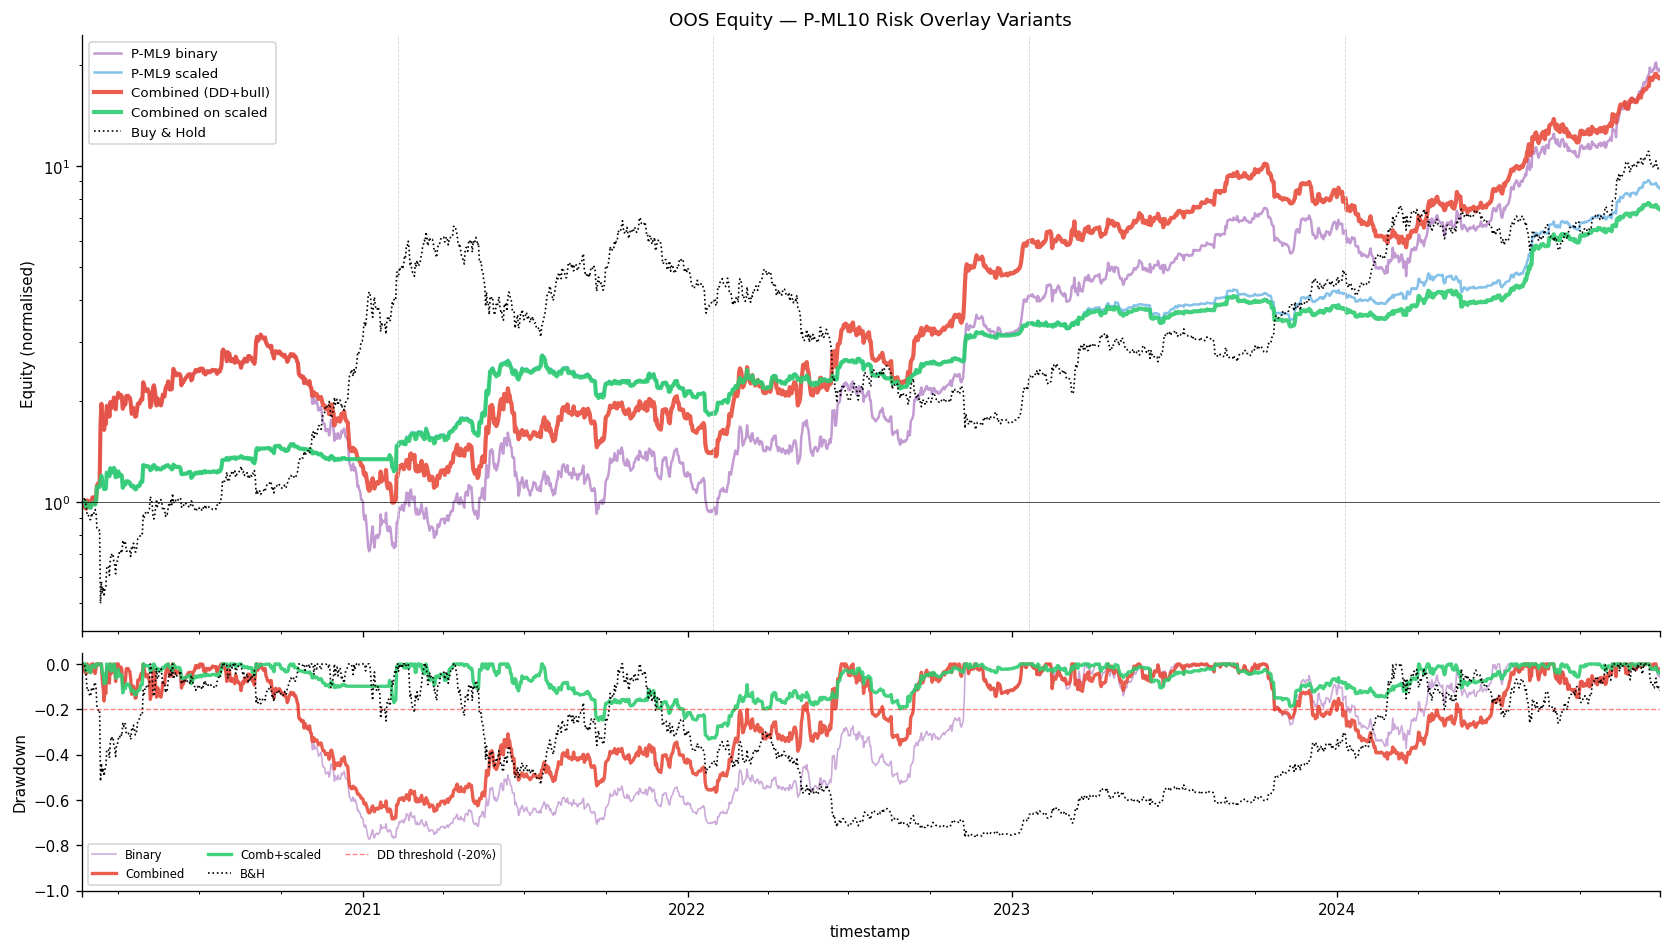

In [6]:
def rolling_drawdown(eq):
    roll_max = eq.cummax()
    return (eq - roll_max) / roll_max

# -- Equity plot ---------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1.2]})

ax = axes[0]
oos_binary.plot(ax=ax, label="P-ML9 binary",       color="#9b59b6", linewidth=1.5, alpha=0.6)
oos_scaled.plot(ax=ax, label="P-ML9 scaled",        color="#3498db", linewidth=1.5, alpha=0.6)
oos_comb.plot(  ax=ax, label="Combined (DD+bull)",   color="#e74c3c", linewidth=2.5, alpha=0.9)
oos_comb_sc.plot(ax=ax, label="Combined on scaled",  color="#2ecc71", linewidth=2.5, alpha=0.9)
bah.plot(       ax=ax, label="Buy & Hold",           color="black",   linewidth=1.0, linestyle=":")
for _, (tr, te) in enumerate(splits):
    ax.axvline(idx[te[0]], color="lightgray", linewidth=0.5, linestyle="--")
ax.axhline(1, color="black", linewidth=0.4)
ax.set_title("OOS Equity — P-ML10 Risk Overlay Variants", fontsize=11)
ax.set_ylabel("Equity (normalised)")
ax.legend(fontsize=8, loc="upper left")
ax.set_yscale("log")

# -- Drawdown plot -------------------------------------------------------------
ax2 = axes[1]
rolling_drawdown(oos_binary).plot(ax=ax2, label="Binary",     color="#9b59b6", linewidth=1.0, alpha=0.5)
rolling_drawdown(oos_comb).plot(  ax=ax2, label="Combined",    color="#e74c3c", linewidth=2.0, alpha=0.9)
rolling_drawdown(oos_comb_sc).plot(ax=ax2, label="Comb+scaled", color="#2ecc71", linewidth=2.0, alpha=0.9)
rolling_drawdown(bah).plot(       ax=ax2, label="B&H",         color="black",   linewidth=1.0, linestyle=":")
ax2.axhline(DD_THRESHOLD, color="red", linewidth=0.8, linestyle="--", alpha=0.5, label=f"DD threshold ({DD_THRESHOLD*100:.0f}%)")
ax2.set_ylabel("Drawdown")
ax2.legend(fontsize=7, loc="lower left", ncol=3)
ax2.set_ylim(-1.0, 0.05)

plt.tight_layout()
plt.show()

## §5 — Drawdown Brake Diagnostics

Examine when the drawdown brake fires: how many bars, which regimes, and the
position reduction profile.

Fold    Test bars  DD active   % active  Bull bars DD in bull
------------------------------------------------------------
  1           355         59      16.6%        178         57
  2           355         49      13.8%        127          0
  3           355         21       5.9%          7          0
  4           355         17       4.8%        207         17
  5           355          0       0.0%        127          0

Total: 146/1775 bars with DD brake active (8.2%)


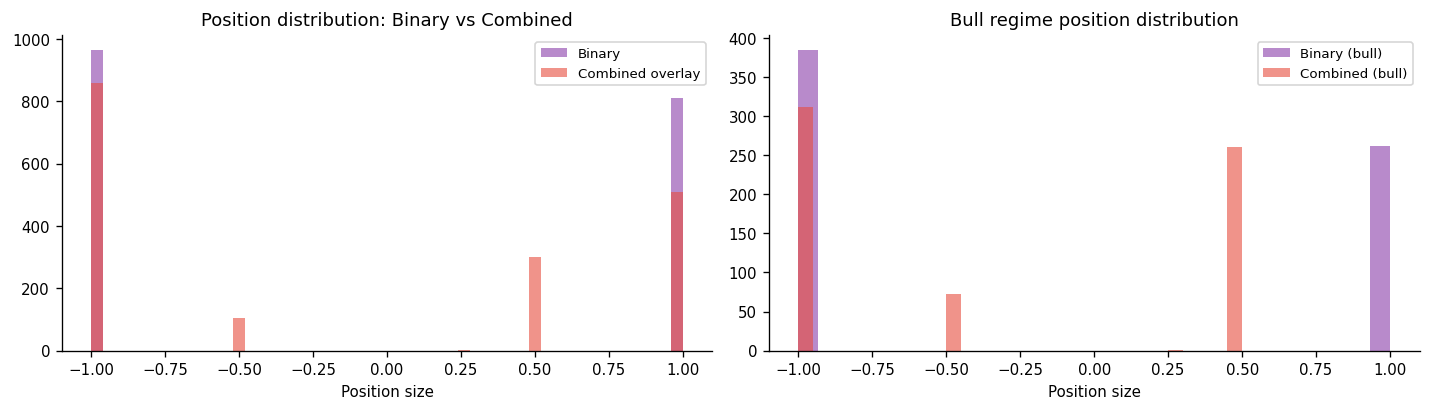

In [7]:
# -- DD brake activation stats --------------------------------------------------
print(f"{'Fold':<6} {'Test bars':>10} {'DD active':>10} {'% active':>10} {'Bull bars':>10} {'DD in bull':>10}")
print("-" * 60)

total_bars = 0
total_dd   = 0
for r in fold_results:
    dd_flag  = r[f"{KEY_COMB}_dd_active"]
    n_bars   = len(r["te"])
    n_dd     = int(dd_flag.sum())
    bull_mask = (r["regimes"] == "bull")
    n_bull   = int(bull_mask.sum())
    n_dd_bull = int((dd_flag & bull_mask).sum())
    total_bars += n_bars
    total_dd   += n_dd
    print(f"  {r['fold']:<4} {n_bars:>10} {n_dd:>10} {n_dd/n_bars*100:>9.1f}% "
          f"{n_bull:>10} {n_dd_bull:>10}")

print(f"\nTotal: {total_dd}/{total_bars} bars with DD brake active ({total_dd/total_bars*100:.1f}%)")

# -- Position distribution comparison -----------------------------------------
all_bin  = pd.concat([r["signals_binary"] for r in fold_results])
all_comb = pd.concat([r[KEY_COMB] for r in fold_results])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].hist(all_bin.values, bins=50, color="#9b59b6", alpha=0.7, label="Binary")
axes[0].hist(all_comb.values, bins=50, color="#e74c3c", alpha=0.6, label="Combined overlay")
axes[0].set_title("Position distribution: Binary vs Combined")
axes[0].set_xlabel("Position size")
axes[0].legend(fontsize=8)

# Bull-only position distribution
all_reg  = pd.concat([r["regimes"] for r in fold_results])
bull_mask = (all_reg == "bull")
axes[1].hist(all_bin[bull_mask].values, bins=30, color="#9b59b6", alpha=0.7, label="Binary (bull)")
axes[1].hist(all_comb[bull_mask].values, bins=30, color="#e74c3c", alpha=0.6, label="Combined (bull)")
axes[1].set_title("Bull regime position distribution")
axes[1].set_xlabel("Position size")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## §6 — Sensitivity Analysis

Test DD brake threshold and bull cap level to check robustness.

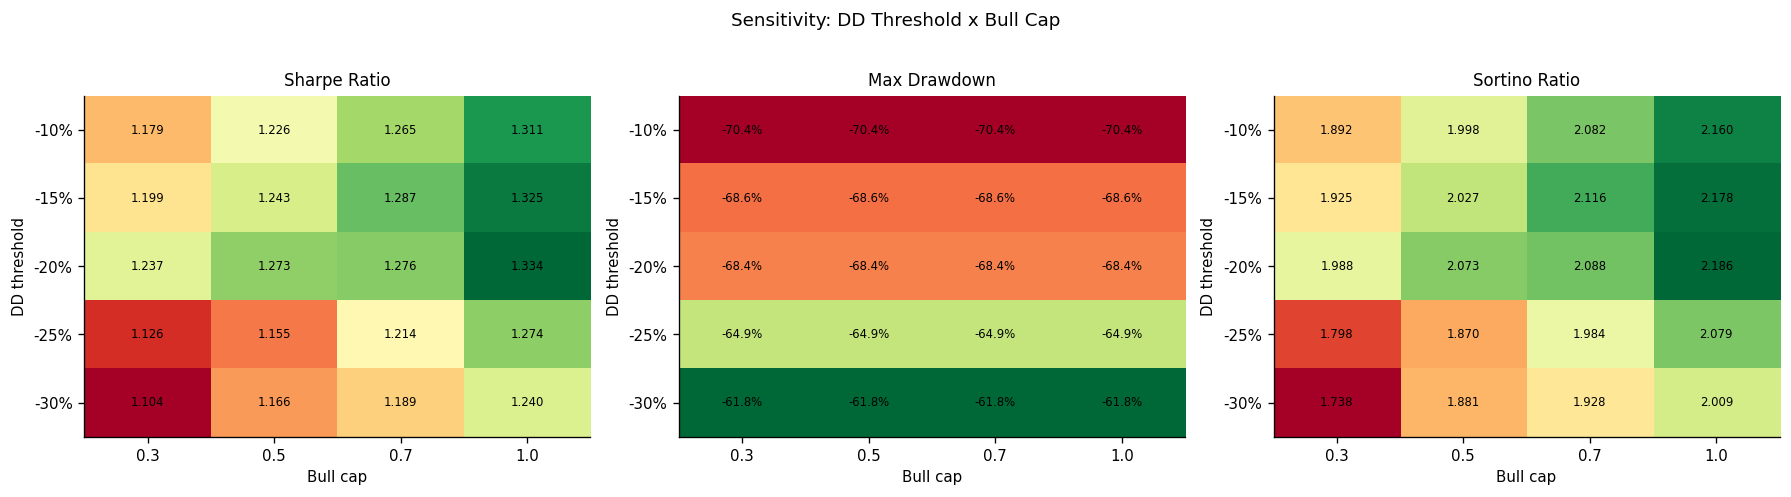


Best Sharpe config: dd_thresh=-20%, bull_cap=1.0
  Sharpe=+1.334, Return=+2318.8%, MaxDD=-68.4%


In [8]:
# -- Sensitivity: DD threshold -------------------------------------------------
dd_thresholds = [-0.10, -0.15, -0.20, -0.25, -0.30]
bull_caps     = [0.3, 0.5, 0.7, 1.0]

sens_results = []

for ddt in dd_thresholds:
    for bc in bull_caps:
        ov = RiskOverlay(
            dd_window=DD_WINDOW, dd_threshold=ddt, dd_multiplier=DD_MULTIPLIER,
            bull_long_cap=bc, enable_dd_brake=True, enable_bull_cap=(bc < 1.0),
        )
        tmp_key = f"_sens_{ddt}_{bc}"
        for r in fold_results:
            res = ov.apply(r["signals_binary"], r["regimes"], r["bar_ret"])
            r[tmp_key] = res.signals
        eq = build_equity_from_signals(fold_results, tmp_key, idx)
        m  = compute_metrics(eq)
        sens_results.append({
            "dd_thresh": ddt, "bull_cap": bc,
            "sharpe": m["sharpe_ratio"], "return": m["total_return"],
            "maxdd": m["max_drawdown"], "sortino": m["sortino_ratio"],
        })
        # Clean up temp keys
        for r in fold_results:
            del r[tmp_key]

sens_df = pd.DataFrame(sens_results)

# -- Heatmap: Sharpe -----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title, fmt in [
    (axes[0], "sharpe",  "Sharpe Ratio",  ".3f"),
    (axes[1], "maxdd",   "Max Drawdown",  ".1%"),
    (axes[2], "sortino", "Sortino Ratio", ".3f"),
]:
    pivot = sens_df.pivot(index="dd_thresh", columns="bull_cap", values=metric)
    im = ax.imshow(pivot.values, cmap="RdYlGn" if metric != "maxdd" else "RdYlGn",
                    aspect="auto")
    ax.set_xticks(range(len(bull_caps)))
    ax.set_xticklabels([f"{x}" for x in bull_caps])
    ax.set_yticks(range(len(dd_thresholds)))
    ax.set_yticklabels([f"{x*100:.0f}%" for x in dd_thresholds])
    ax.set_xlabel("Bull cap")
    ax.set_ylabel("DD threshold")
    ax.set_title(title, fontsize=10)
    for yi in range(len(dd_thresholds)):
        for xi in range(len(bull_caps)):
            val = pivot.values[yi, xi]
            text = f"{val:{fmt}}" if metric != "maxdd" else f"{val*100:.1f}%"
            ax.text(xi, yi, text, ha="center", va="center", fontsize=7)

plt.suptitle("Sensitivity: DD Threshold x Bull Cap", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# -- Best config ---------------------------------------------------------------
best = sens_df.loc[sens_df["sharpe"].idxmax()]
print(f"\nBest Sharpe config: dd_thresh={best['dd_thresh']:.0%}, bull_cap={best['bull_cap']}")
print(f"  Sharpe={best['sharpe']:+.3f}, Return={best['return']*100:+.1f}%, MaxDD={best['maxdd']*100:.1f}%")

# Best risk-adjusted (highest Sharpe among configs with MaxDD > -40%)
safe = sens_df[sens_df["maxdd"] > -0.40]
if len(safe) > 0:
    best_safe = safe.loc[safe["sharpe"].idxmax()]
    print(f"\nBest Sharpe with MaxDD > -40%: dd_thresh={best_safe['dd_thresh']:.0%}, bull_cap={best_safe['bull_cap']}")
    print(f"  Sharpe={best_safe['sharpe']:+.3f}, Return={best_safe['return']*100:+.1f}%, MaxDD={best_safe['maxdd']*100:.1f}%")

## §7 — Per-Fold Breakdown

Analyse which folds benefit most from the overlay and where it hurts.

In [9]:
# -- Per-fold metrics: binary vs combined overlay ------------------------------
print(f"{'Fold':<6} {'Period':<28} {'Binary':>20} {'Combined overlay':>20} {'Delta':>10}")
print(f"{'':6} {'':28} {'Sharpe / MaxDD':>20} {'Sharpe / MaxDD':>20} {'Sharpe':>10}")
print("-" * 88)

for r in fold_results:
    te = r["te"]
    period = f"{comb.index[te[0]].date()} -> {comb.index[te[-1]].date()}"

    # Binary equity for this fold
    pos_b = r["signals_binary"].values
    ret   = r["bar_ret"].values
    pos_sh = np.roll(pos_b, 1); pos_sh[0] = 0
    eq_b = pd.Series(np.cumprod(1 + pos_sh * ret), index=comb.index[te])
    m_b  = compute_metrics(eq_b)

    # Combined overlay equity for this fold
    pos_c = r[KEY_COMB].values
    pos_sh = np.roll(pos_c, 1); pos_sh[0] = 0
    eq_c = pd.Series(np.cumprod(1 + pos_sh * ret), index=comb.index[te])
    m_c  = compute_metrics(eq_c)

    d_sharpe = m_c["sharpe_ratio"] - m_b["sharpe_ratio"]
    print(f"  {r['fold']:<4} {period:<28} "
          f"{m_b['sharpe_ratio']:>+7.3f} / {m_b['max_drawdown']*100:>6.1f}%  "
          f"{m_c['sharpe_ratio']:>+7.3f} / {m_c['max_drawdown']*100:>6.1f}%  "
          f"{d_sharpe:>+9.3f}")

Fold   Period                                     Binary     Combined overlay      Delta
                                          Sharpe / MaxDD       Sharpe / MaxDD     Sharpe
----------------------------------------------------------------------------------------
  1    2020-02-20 -> 2021-02-08      +0.238 /  -77.3%   +0.592 /  -68.4%     +0.354
  2    2021-02-09 -> 2022-01-29      +0.485 /  -42.6%   +0.581 /  -35.9%     +0.096
  3    2022-01-30 -> 2023-01-19      +2.687 /  -35.2%   +2.673 /  -35.8%     -0.015
  4    2023-01-20 -> 2024-01-09      +1.264 /  -26.9%   +0.945 /  -24.2%     -0.319
  5    2024-01-10 -> 2024-12-29      +2.423 /  -27.0%   +2.155 /  -28.6%     -0.268


## §8 — Finding F17 Summary

In [10]:
# -- Final comparison table -----------------------------------------------------
m_comb   = results["Combined (DD+bull)"]
m_comb_s = results["Combined on scaled"]
m_bin    = results["P-ML9 binary"]
m_sc     = results["P-ML9 scaled"]
m_bah    = results["Buy & Hold"]

print("=" * 78)
print("FINDING F17 -- Risk Overlay (P-ML10)")
print("=" * 78)
print()
print(f"RiskOverlay class created in ml/risk/overlay.py")
print(f"  DD brake:  window={DD_WINDOW}, threshold={DD_THRESHOLD}, mult={DD_MULTIPLIER}")
print(f"  Bull cap:  max_long={BULL_LONG_CAP}")
print()
print(f"{'Strategy':<32} {'Return':>10} {'Sharpe':>8} {'Sortino':>9} {'MaxDD':>8} {'Calmar':>8}")
print("-" * 80)
rows = [
    ("Buy & Hold",           m_bah),
    ("P-ML9 binary (ref)",   m_bin),
    ("P-ML9 scaled (ref)",   m_sc),
    ("DD brake only",        results["DD brake only"]),
    ("Bull cap only",        results["Bull cap only"]),
    ("Combined (DD+bull)",   m_comb),
    ("Combined on scaled",   m_comb_s),
]
for name, m in rows:
    print(f"  {name:<30} {m['total_return']*100:>+9.1f}%  {m['sharpe_ratio']:>+7.3f}"
          f"  {m['sortino_ratio']:>+8.3f}  {m['max_drawdown']*100:>7.1f}%"
          f"  {m['calmar_ratio']:>7.2f}")

print()

# -- Hypothesis evaluation -----------------------------------------------------
comb_sharpe_beats_bah = m_comb["sharpe_ratio"] > BUY_HOLD["sharpe"]
comb_maxdd_improved   = m_comb["max_drawdown"] > P_ML7["maxdd"]
comb_sc_beats_bah     = m_comb_s["sharpe_ratio"] > BUY_HOLD["sharpe"]

print("Hypothesis H2 evaluation:")
print(f"  Combined overlay MaxDD improved vs binary? "
      f"{'YES' if comb_maxdd_improved else 'NO'} "
      f"({m_comb['max_drawdown']*100:.1f}% vs {P_ML7['maxdd']*100:.1f}%)")
print(f"  Combined overlay Sharpe beats B&H?         "
      f"{'YES' if comb_sharpe_beats_bah else 'NO'} "
      f"({m_comb['sharpe_ratio']:+.3f} vs {BUY_HOLD['sharpe']:+.3f})")
print(f"  Combined-on-scaled Sharpe beats B&H?       "
      f"{'YES' if comb_sc_beats_bah else 'NO'} "
      f"({m_comb_s['sharpe_ratio']:+.3f} vs {BUY_HOLD['sharpe']:+.3f})")
print()

# Determine best variant
best_name, best_m = max(
    [(n, m) for n, m in rows if n not in ("Buy & Hold",)],
    key=lambda x: x[1]["sharpe_ratio"],
)
print(f"Best variant: {best_name}")
print(f"  Sharpe={best_m['sharpe_ratio']:+.3f}, Return={best_m['total_return']*100:+.1f}%, "
      f"MaxDD={best_m['max_drawdown']*100:.1f}%")
print()
print("Next steps:")
print("  - If MaxDD still too high: test tighter DD threshold (-15%) or lower bull cap (0.3)")
print("  - H4: HMM regime classifier for late-bull detection (structural fix for Fold 2)")
print("  - H5: Optuna tuning on the 16-feature model (low priority)")

FINDING F17 -- Risk Overlay (P-ML10)

RiskOverlay class created in ml/risk/overlay.py
  DD brake:  window=30, threshold=-0.2, mult=0.5
  Bull cap:  max_long=0.5

Strategy                             Return   Sharpe   Sortino    MaxDD   Calmar
--------------------------------------------------------------------------------
  Buy & Hold                        +876.6%   +1.052    +1.394    -76.6%     0.78
  P-ML9 binary (ref)               +1815.4%   +1.234    +2.010    -77.3%     1.08
  P-ML9 scaled (ref)                +758.7%   +1.583    +2.323    -33.6%     1.65
  DD brake only                    +2318.8%   +1.334    +2.186    -68.4%     1.35
  Bull cap only                    +1239.4%   +1.146    +1.841    -77.3%     0.91
  Combined (DD+bull)               +1728.8%   +1.273    +2.073    -68.4%     1.20
  Combined on scaled                +645.9%   +1.518    +2.201    -33.2%     1.54

Hypothesis H2 evaluation:
  Combined overlay MaxDD improved vs binary? YES (-68.4% vs -77.3%)
  Combi